<a href="https://colab.research.google.com/github/penajuanmanuel6-hub/automated-etl-pipeline/blob/main/analisis_impactos_sismicos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- 1. CONFIGURACIÓN DE LA BASE DE DATOS Y CARGA DE DATOS (SQL) ---
Base de datos estructurada y poblada correctamente.

--- 2. EJECUCIÓN DE LA CONSULTA SQL DE AGREGACIÓN Y PRIORIZACIÓN ---
                 Sector  Impacto_USD_Millones  Empleos_Afectados  Impacto_Sobre_PIB_Pct   Nivel_Prioridad_SQL
   Infraestructura Vial                1200.0              45000                  24.00 Crítica - Prioridad 1
Vivienda y Habitacional                 950.0             120000                  11.88    Alta - Prioridad 2
     Comercio y Turismo                 600.0              85000                   8.57    Alta - Prioridad 2
Industria Manufacturera                 450.0              60000                   5.00    Alta - Prioridad 2
      Salud y Educación                 300.0              35000                   7.50    Alta - Prioridad 2
            Agricultura                 200.0              50000                   6.67    Alta - Prioridad 2


--- 3. GENERACIÓN DE GRÁFICO EJECUTIVO

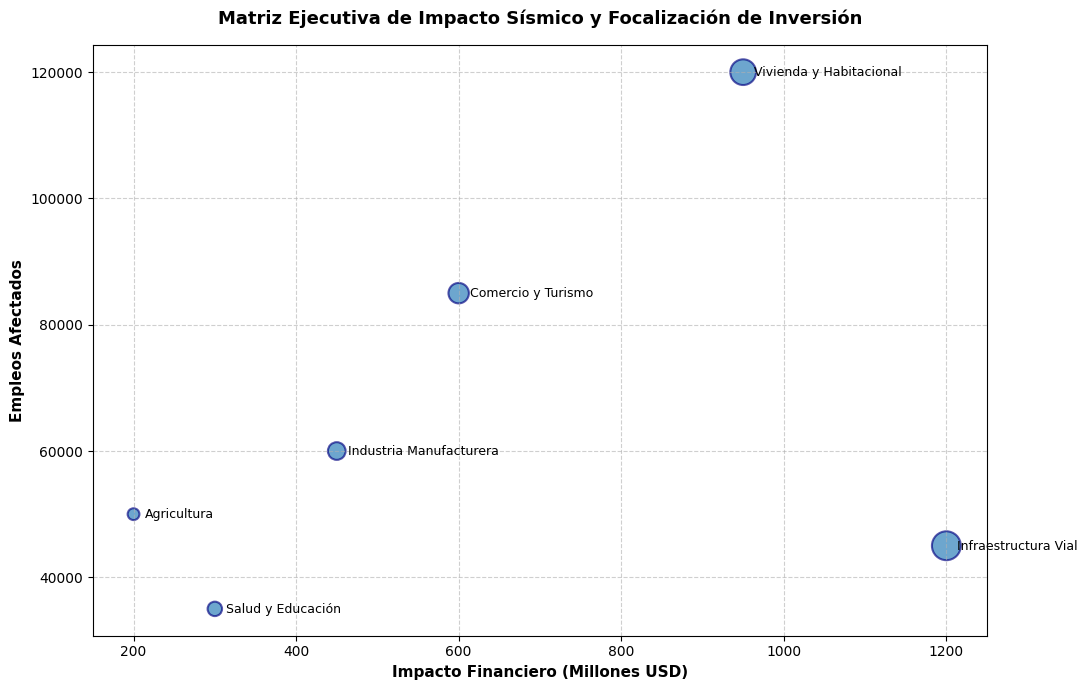

In [3]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIGURACIÓN DE LA BASE DE DATOS Y CARGA (ETL / SQL)
# ==========================================
print("--- 1. CONFIGURACIÓN DE LA BASE DE DATOS Y CARGA DE DATOS (SQL) ---")

# Creamos una base de datos SQLite en memoria
conn = sqlite3.connect(":memory:")
cursor = conn.cursor()

# Creación de la tabla de impactos sísmicos y socioeconómicos
cursor.execute("""
CREATE TABLE impactos_sismicos (
    id_impacto INTEGER PRIMARY KEY AUTOINCREMENT,
    sector TEXT,
    impacto_usd_millones REAL,
    empleos_afectados INTEGER,
    impacto_pib_pct REAL,
    nivel_prioridad TEXT
)
""")

# Datos de muestra estructurados
datos_iniciales = [
    ('Infraestructura Vial', 1200.0, 45000, 24.00, 'Crítica - Prioridad 1'),
    ('Vivienda y Habitacional', 950.0, 120000, 11.88, 'Alta - Prioridad 2'),
    ('Comercio y Turismo', 600.0, 85000, 8.57, 'Alta - Prioridad 2'),
    ('Industria Manufacturera', 450.0, 60000, 5.00, 'Alta - Prioridad 2'),
    ('Salud y Educación', 300.0, 35000, 7.50, 'Alta - Prioridad 2'),
    ('Agricultura', 200.0, 50000, 6.67, 'Alta - Prioridad 2')
]

cursor.executemany("""
INSERT INTO impactos_sismicos (sector, impacto_usd_millones, empleos_afectados, impacto_pib_pct, nivel_prioridad)
VALUES (?, ?, ?, ?, ?)
""", datos_iniciales)

conn.commit()
print("Base de datos estructurada y poblada correctamente.\n")

# ==========================================
# 2. EJECUCIÓN DE LA CONSULTA SQL DE AGREGACIÓN
# ==========================================
print("--- 2. EJECUCIÓN DE LA CONSULTA SQL DE AGREGACIÓN Y PRIORIZACIÓN ---")

query_sql = """
SELECT
    sector AS Sector,
    impacto_usd_millones AS Impacto_USD_Millones,
    empleos_afectados AS Empleos_Afectados,
    impacto_pib_pct AS Impacto_Sobre_PIB_Pct,
    nivel_prioridad AS Nivel_Prioridad_SQL
FROM impactos_sismicos
ORDER BY impacto_usd_millones DESC;
"""

df = pd.read_sql_query(query_sql, conn)

# Mostramos el resultado estructurado tipo tabla analítica
print(df.to_string(index=False))
print("\n")

# Cerramos la conexión a la base de datos
conn.close()

# ==========================================
# 3. GENERACIÓN DE GRÁFICO EJECUTIVO CON MATPLOTLIB
# ==========================================
print("--- 3. GENERACIÓN DE GRÁFICO EJECUTIVO (MATPLOTLIB) ---")

# Asignamos un puntaje proporcional para el tamaño de las burbujas/puntos
df['Score_Prioridad'] = df['Impacto_USD_Millones'] / 50

plt.figure(figsize=(11, 7))
plt.scatter(
    df['Impacto_USD_Millones'],
    df['Empleos_Afectados'],
    s=df['Score_Prioridad'] * 18,  # Tamaño dinámico de la burbuja
    color='#1f77b4',
    alpha=0.65,
    edgecolors='navy',
    linewidth=1.5
)

# Estética y rotulados profesionales
plt.title("Matriz Ejecutiva de Impacto Sísmico y Focalización de Inversión", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Impacto Financiero (Millones USD)", fontsize=11, fontweight='semibold')
plt.ylabel("Empleos Afectados", fontsize=11, fontweight='semibold')
plt.grid(True, linestyle='--', alpha=0.6)

# Anotaciones de etiquetas en cada punto para lectura inmediata
for i, txt in enumerate(df['Sector']):
    plt.annotate(
        txt,
        (df['Impacto_USD_Millones'][i], df['Empleos_Afectados'][i]),
        fontsize=9,
        fontweight='medium',
        xytext=(8, -3),
        textcoords='offset points'
    )

plt.tight_layout()
plt.show()